In [1]:
from asmcmc.potentials import CACELLI_POTENTIAL, calc_total_energy

import ase.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
frames = ase.io.read("../data/xyz_files/duped_ellipsoids_with_axes.xyz", index=":")

In [3]:
NL_CUTOFF = 7.5

gbq_energies = []
for frame in frames:
    energy = calc_total_energy(frame, NL_CUTOFF, CACELLI_POTENTIAL)
    gbq_energies.append(energy)
    
gbq_energies = np.array(gbq_energies)

In [4]:
en_frames = ase.io.read("../data/xyz_files/ellipsoids_with_axes_and_energies.xyz", ":")

In [5]:
for i, frame in enumerate(en_frames):
    print(f"{frame.get_total_energy():.6f}  {(frame.info["energy_pa"] * 12):.6f}  {(gbq_energies[i] / len(frames[i])):.6f}")
    if i >= 15:
        break

-3202.950979  -1601.475490  -0.145452
-1601.559382  -1601.559382  -0.128696
-1601.553376  -1601.553376  -0.121850
-3203.150910  -1601.575455  -0.132013
-3202.687756  -1601.343878  -0.134543
-3202.891504  -1601.445752  -0.122274
-1601.414237  -1601.414237  -0.105428
-3201.090824  -1600.545412  -0.041635
-3201.333854  -1600.666927  0.162019
-3203.103034  -1601.551517  -0.133082
-3200.988533  -1600.494266  0.034156
-3203.040580  -1601.520290  -0.134921
-1600.572989  -1600.572989  0.123846
-1599.808682  -1599.808682  0.871304
-1597.754400  -1597.754400  2.080980
-3199.801603  -1599.900802  0.379374


In [6]:
per_mol_dft = [frame.info["energy_pa"] * 12 for frame in en_frames]
intramol_dft = np.mean(per_mol_dft)
intermolecular_dft = [en - intramol_dft for en in per_mol_dft]
per_mol_gbq = [gbq_energies[i] / len(frames[i]) for i in range(len(gbq_energies))]

print(f"gbq mean: {np.mean(per_mol_gbq)}")
print(f"gbq std: {np.std(per_mol_gbq)}")
print(f"dft mean: {np.mean(intermolecular_dft)}")
print(f"dft std: {np.std(intermolecular_dft)}")

gbq mean: 0.023196288368544263
gbq std: 0.5404026040361211
dft mean: -1.3663738890538205e-13
dft std: 0.7034144305273197


In [7]:
df = pd.DataFrame({"gbq": per_mol_gbq, "dft": intermolecular_dft})
df

,gbq,dft
0,-0.145452,-0.402806
1,-0.128696,-0.486699
2,-0.121850,-0.480693
3,-0.132013,-0.502772
4,-0.134543,-0.271195
...,...,...
6821,-0.042380,0.537950
6822,-0.116786,-0.086878
6823,-0.144490,-0.489367
6824,0.011617,0.715183


## Evaluating GBQ vs DFT

Diagnostics for how well Cacelli's GBQIII reproduces the DFT intermolecular energies (per
molecule, eV):

- **Parity** — GBQ vs DFT against $y=x$. *All frames* as a log-density hexbin (exposing the ~180
  hard-core-overlap frames whose repulsive energy runs to several eV/mol), alongside the
  physically-sampled *bulk* (GBQ ≤ 1 eV/mol), where a least-squares slope quantifies the
  compressed energy scale.
- **Error distribution** — histogram of the bulk residuals, and residual vs DFT energy, whose
  clean negative trend is GBQ under-predicting the high-energy (repulsive) configurations.
- **Form vs parameters** — the same parity for Cacelli's published params next to the GB+Q form
  *refit to this dataset* (`DEFAULT_POTENTIAL`), separating miscalibration from the ceiling of the
  analytical form.

Cacelli's GBQIII tracks DFT in rank (Pearson $r \approx 0.85$ on the bulk) but with a badly
compressed scale (slope $\approx 0.27$, RMS $\approx 10$ kcal/mol). Most of that is *wrong
parameters for this dataset*, not the functional form: refitting the same GB+Q form pulls the
slope to $\approx 0.77$ and the RMS to $\approx 3$ kcal/mol (mean-referenced). But the refit
*plateaus* there — slope still $< 1$, and $\approx 3$ kcal/mol is comparable to the slipped-parallel
dimer well ($-2.5$ kcal/mol) that selects the crystal, so relative phase energies stay unreliable.
That form-limited floor — not Cacelli's miscalibration — is what motivates a systematically
improvable representation (AniSOAP).

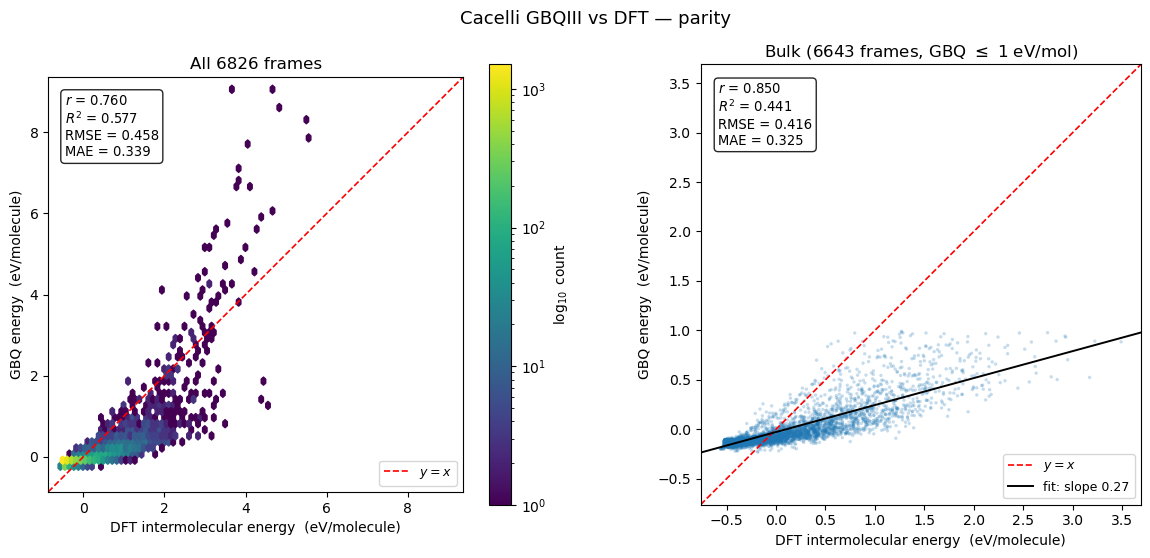

In [8]:
import os

# per-molecule energies straight from the tidy frame above
gbq_pm = df["gbq"].to_numpy()
dft_pm = df["dft"].to_numpy()

FIGDIR = "../results/validation/figures"
os.makedirs(FIGDIR, exist_ok=True)

# hard-core overlap frames sit on the repulsive wall (GBQ up to ~9 eV/mol) and
# dominate any RMS; separate them from the physically-sampled bulk.
overlap = gbq_pm > 1.0
bulk = ~overlap


def metrics(pred, true):
    """Pearson r, R^2 about y = x, RMSE, MAE (all eV/molecule)."""
    r = np.corrcoef(pred, true)[0, 1]
    rmse = np.sqrt(np.mean((pred - true) ** 2))
    mae = np.mean(np.abs(pred - true))
    r2 = 1.0 - np.sum((true - pred) ** 2) / np.sum((true - true.mean()) ** 2)
    return r, r2, rmse, mae


def stat_box(ax, pred, true):
    r, r2, rmse, mae = metrics(pred, true)
    ax.text(0.04, 0.96,
            f"$r$ = {r:.3f}\n$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}",
            transform=ax.transAxes, va="top", ha="left", fontsize=9.5,
            bbox=dict(boxstyle="round", fc="white", alpha=0.85))


fig, (ax_all, ax_bulk) = plt.subplots(1, 2, figsize=(12, 5.6))

# left: every frame, log-density hexbin -- exposes the overlap tail
lims = [min(dft_pm.min(), gbq_pm.min()) - 0.3, max(dft_pm.max(), gbq_pm.max()) + 0.3]
hb = ax_all.hexbin(dft_pm, gbq_pm, gridsize=55, bins="log", cmap="viridis", mincnt=1)
ax_all.plot(lims, lims, "r--", lw=1.2, label="$y = x$")
ax_all.set_xlim(lims); ax_all.set_ylim(lims)
ax_all.set_title(f"All {len(df)} frames")
fig.colorbar(hb, ax=ax_all, label=r"$\log_{10}$ count")
stat_box(ax_all, gbq_pm, dft_pm)

# right: bulk only, with the least-squares slope -- shows the compressed energy scale
d, g = dft_pm[bulk], gbq_pm[bulk]
lims_b = [d.min() - 0.2, d.max() + 0.2]
ax_bulk.scatter(d, g, s=6, alpha=0.25, edgecolors="none", color="tab:blue")
ax_bulk.plot(lims_b, lims_b, "r--", lw=1.2, label="$y = x$")
slope, intercept = np.polyfit(d, g, 1)
xx = np.array(lims_b)
ax_bulk.plot(xx, slope * xx + intercept, "k-", lw=1.4, label=f"fit: slope {slope:.2f}")
ax_bulk.set_xlim(lims_b); ax_bulk.set_ylim(lims_b)
ax_bulk.set_title(f"Bulk ({int(bulk.sum())} frames, GBQ $\\leq$ 1 eV/mol)")
stat_box(ax_bulk, g, d)

for ax in (ax_all, ax_bulk):
    ax.set_xlabel("DFT intermolecular energy  (eV/molecule)")
    ax.set_ylabel("GBQ energy  (eV/molecule)")
    ax.legend(loc="lower right", fontsize=9)
    ax.set_aspect("equal", "box")
fig.suptitle("Cacelli GBQIII vs DFT — parity", fontsize=13)
fig.tight_layout()
fig.savefig(f"{FIGDIR}/gbq_vs_dft_parity.png", dpi=200, bbox_inches="tight")
plt.show()

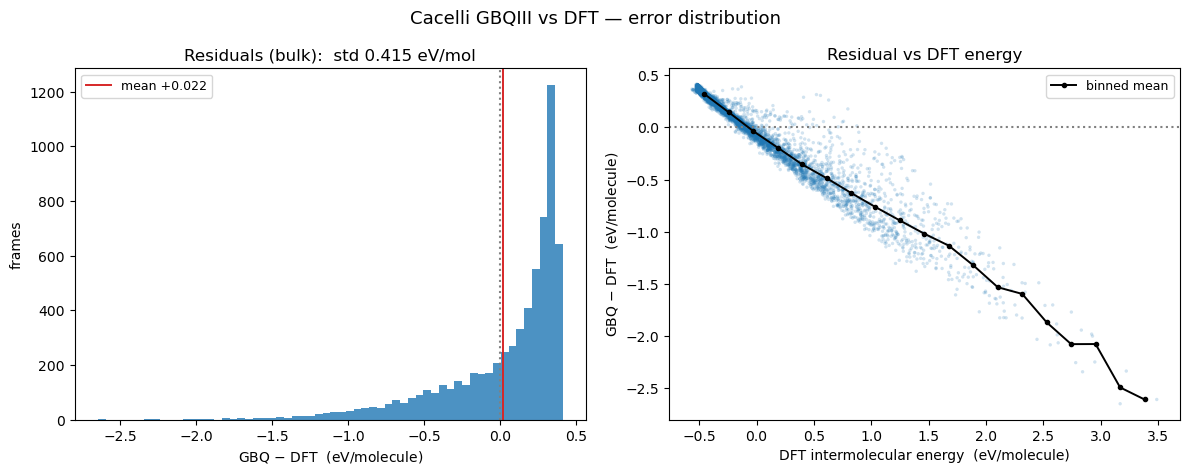

In [9]:
# residuals on the bulk (overlap frames excluded)
d, g = dft_pm[bulk], gbq_pm[bulk]
resid = g - d

fig, (ax_h, ax_r) = plt.subplots(1, 2, figsize=(12, 4.8))

ax_h.hist(resid, bins=60, color="tab:blue", alpha=0.8)
ax_h.axvline(0, color="0.5", ls=":")
ax_h.axvline(resid.mean(), color="tab:red", lw=1.4, label=f"mean {resid.mean():+.3f}")
ax_h.set_xlabel("GBQ $-$ DFT  (eV/molecule)")
ax_h.set_ylabel("frames")
ax_h.set_title(f"Residuals (bulk):  std {resid.std():.3f} eV/mol")
ax_h.legend(fontsize=9)

# residual vs DFT energy: the compressed scale shows up as a clean negative trend --
# where DFT sees a high-energy (repulsive) config, GBQ's shallow wall under-predicts it
ax_r.axhline(0, color="0.5", ls=":")
ax_r.scatter(d, resid, s=6, alpha=0.2, edgecolors="none", color="tab:blue")
edges = np.linspace(d.min(), d.max(), 20)
centers = 0.5 * (edges[:-1] + edges[1:])
bidx = np.clip(np.digitize(d, edges) - 1, 0, len(centers) - 1)
trend = np.array([resid[bidx == b].mean() if np.any(bidx == b) else np.nan
                  for b in range(len(centers))])
ax_r.plot(centers, trend, "k-o", ms=3, lw=1.4, label="binned mean")
ax_r.set_xlabel("DFT intermolecular energy  (eV/molecule)")
ax_r.set_ylabel("GBQ $-$ DFT  (eV/molecule)")
ax_r.set_title("Residual vs DFT energy")
ax_r.legend(fontsize=9)

fig.suptitle("Cacelli GBQIII vs DFT — error distribution", fontsize=13)
fig.tight_layout()
fig.savefig(f"{FIGDIR}/gbq_vs_dft_residuals.png", dpi=200, bbox_inches="tight")
plt.show()

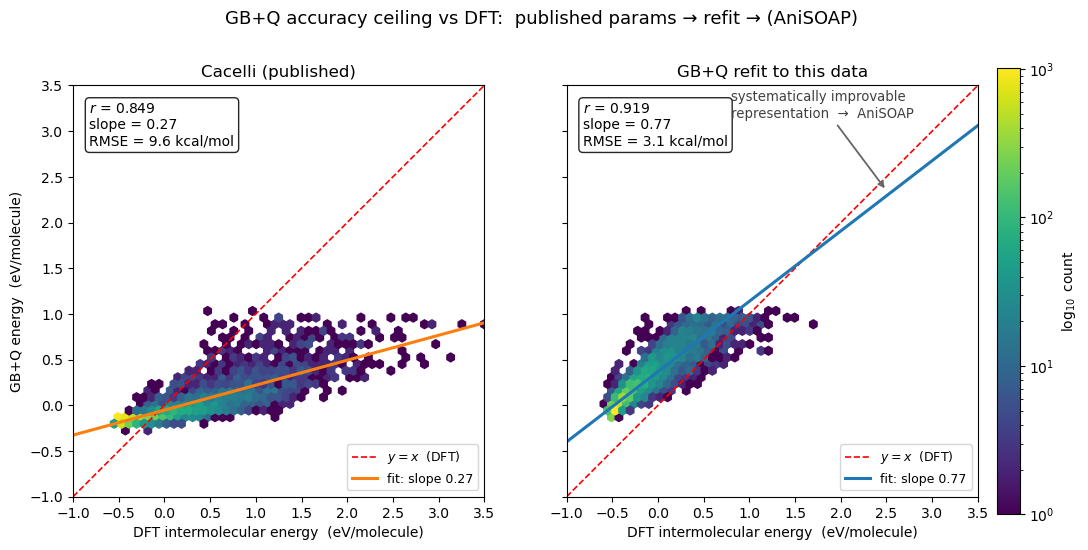

In [10]:
from asmcmc.potentials import DEFAULT_POTENTIAL

# Is the Cacelli-vs-DFT gap above the GB+Q *form* or just its *parameters*? Refit the
# same form to this data (DEFAULT_POTENTIAL) and compare. Both are recomputed here at a
# common converged cutoff -- the refit's larger sigma0 (7.07 vs 5.72 A) outruns cell 2's
# 7.5 A, so 7.5 would truncate it unfairly. (~5 min: two full-set energy passes.) RMSE is
# mean-referenced -- the constant offset the fit absorbs is removed, not charged to it.
EV2KCAL = 23.060541945329334
CUT_FAIR = 10.0

import os
FIGDIR = "../results/validation/figures"
os.makedirs(FIGDIR, exist_ok=True)

n_mol = np.array([len(f) for f in frames])
dft_pm = df["dft"].to_numpy()
e_cac = np.array([calc_total_energy(f, CUT_FAIR, CACELLI_POTENTIAL) for f in frames]) / n_mol
e_ref = np.array([calc_total_energy(f, CUT_FAIR, DEFAULT_POTENTIAL) for f in frames]) / n_mol

series = [("Cacelli (published)", e_cac, "tab:orange"),
          ("GB+Q refit to this data", e_ref, "tab:blue")]

lims = [-1.0, 3.5]
fig, axs = plt.subplots(1, 2, figsize=(12.5, 5.8), sharex=True, sharey=True)
for ax, (label, e, color) in zip(axs, series):
    bulk = e <= 1.0
    d, g = dft_pm[bulk], e[bulk]
    hb = ax.hexbin(d, g, gridsize=55, bins="log", cmap="viridis", mincnt=1,
                   extent=(lims[0], lims[1], lims[0], lims[1]))
    ax.plot(lims, lims, "r--", lw=1.2, label="$y = x$  (DFT)")
    slope, intercept = np.polyfit(d, g, 1)
    xx = np.array(lims)
    ax.plot(xx, slope * xx + intercept, "-", color=color, lw=2.2, label=f"fit: slope {slope:.2f}")
    r = np.corrcoef(g, d)[0, 1]
    rmse_kcal = np.sqrt(np.mean(((g - g.mean()) - (d - d.mean())) ** 2)) * EV2KCAL
    ax.text(0.04, 0.96, f"$r$ = {r:.3f}\nslope = {slope:.2f}\nRMSE = {rmse_kcal:.1f} kcal/mol",
            transform=ax.transAxes, va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round", fc="white", alpha=0.85))
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("DFT intermolecular energy  (eV/molecule)")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect("equal", "box")
    ax.legend(loc="lower right", fontsize=9)
axs[0].set_ylabel("GB+Q energy  (eV/molecule)")

# the refit closes most of the parameter gap but plateaus (slope < 1, RMS ~ the
# -2.5 kcal/mol dimer well) -- that form-limited floor is the opening for AniSOAP
axs[1].annotate("systematically improvable\nrepresentation  →  AniSOAP",
                xy=(2.5, 2.35), xytext=(0.8, 3.15), fontsize=9.5, color="0.25", ha="left",
                arrowprops=dict(arrowstyle="->", color="0.4", lw=1.3))
fig.colorbar(hb, ax=axs, fraction=0.046, pad=0.02, label=r"$\log_{10}$ count")
fig.suptitle("GB+Q accuracy ceiling vs DFT:  published params → refit → (AniSOAP)",
             fontsize=13)
fig.savefig(f"{FIGDIR}/gbq_refit_vs_dft_parity.png", dpi=200, bbox_inches="tight")
plt.show()